In [62]:
!pip install xgboost catboost faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 8.3 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks', 'ML_Datasets', 'Machine_Learning700_Assignment.ipynb']

In [9]:
import os

os.listdir('/content/drive/MyDrive/ML_Datasets')

['2025_paliament.pdf',
 '2024_paliament.pdf',
 '2024_part 2 paliamnet.pdf',
 '2023 paliament.pdf',
 '2023 part 2 paliament.pdf',
 'paliament 2022.pdf',
 'part 2 2022 paliament.pdf',
 'part 2 2025 paliament.pdf',
 'South Africa Road Accidents Dataset - 2017.xlsx']

In [15]:
import pandas as pd

data = pd.read_excel(r'/content/drive/MyDrive/ML_Datasets/South Africa Road Accidents Dataset - 2017.xlsx')

data.head()

,AccidentNo,Location,Police Force,Accident Severity,Number of Vehicles,Vehicle Type,Speed (km/h),Speed Zone,Number of Casualties,Year,Date,Time,Occations,Province,City,Street Name
0,1,Residential Area,2,Bumper Accident,6,Motocar,90km/h,60KM,1,2016,2018-01-01,22:00:00,Normal day,Gauteng,Pretoria,Mandela Street
1,2,Residential Area,2,Bumper Accident,6,Minibus,90km/h,60KM,1,2016,2018-01-02,23:00:00,Normal day,Gauteng,Pretoria,Mandela Street
2,3,Residential Area,2,Bumper Accident,6,Minibus Taxi,90km/h,60KM,1,2016,2018-01-03,1900-01-01 00:00:00,Normal day,Gauteng,Pretoria,Mandela Street
3,4,Residential Area,2,Bumper Accident,6,Bus,90km/h,60KM,1,2016,2018-01-04,1900-01-01 01:00:00,Normal day,Gauteng,Pretoria,Mandela Street
4,5,Residential Area,2,Bumper Accident,6,Motorcycle,90km/h,60KM,1,2016,2018-01-05,1900-01-01 02:00:00,Normal day,Gauteng,Pretoria,Mandela Street


In [16]:
import pandas as pd

data = pd.read_excel(r'/content/drive/MyDrive/ML_Datasets/South Africa Road Accidents Dataset - 2017.xlsx')

print("dataset shape:")
print(data.shape)

#show column names
print("\nColumns Names:")
print(data.columns)

#show missing vaues
print("\nMissing values:")
print(data.isnull().sum())

dataset shape:
(120, 16)

Columns Names:
Index(['AccidentNo', 'Location', 'Police Force', 'Accident Severity',
       'Number of Vehicles', 'Vehicle Type', 'Speed (km/h)', 'Speed Zone',
       'Number of Casualties', 'Year', 'Date', 'Time', 'Occations', 'Province',
       'City', 'Street Name'],
      dtype='object')

Missing values:
AccidentNo              0
Location                0
Police Force            0
Accident Severity       0
Number of Vehicles      0
Vehicle Type            0
Speed (km/h)            0
Speed Zone              0
Number of Casualties    0
Year                    0
Date                    0
Time                    0
Occations               0
Province                0
City                    0
Street Name             0
dtype: int64


In [17]:
print(data['Accident Severity'].value_counts())


Accident Severity
Headon Accident    56
Bumper Accident    33
Fatal Accident     31
Name: count, dtype: int64


In [18]:
#inpud data which is a feature
X=data.drop('Accident Severity',axis=1)

#target which what we want to predict
y= data['Accident Severity']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (120, 15)
Target shape: (120,)


In [20]:
from sklearn.preprocessing import LabelEncoder
#creating an encoder
label_encoder=LabelEncoder()

# encode all categorical columns
for column in X.columns:
  if X[column].dtype == 'object':
    # Convert problematic datetime objects to string before encoding
    X[column] = X[column].astype(str)
    X[column] = label_encoder.fit_transform(X[column])

# Encode target variables once
y=label_encoder.fit_transform(y)

#view encoded data
X.head()

,AccidentNo,Location,Police Force,Number of Vehicles,Vehicle Type,Speed (km/h),Speed Zone,Number of Casualties,Year,Date,Time,Occations,Province,City,Street Name
0,1,2,2,6,5,2,1,1,2016,2018-01-01,118,2,1,5,1
1,2,2,2,6,3,2,1,1,2016,2018-01-02,119,2,1,5,1
2,3,2,2,6,4,2,1,1,2016,2018-01-03,0,2,1,5,1
3,4,2,2,6,2,2,1,1,2016,2018-01-04,1,2,1,5,1
4,5,2,2,6,6,2,1,1,2016,2018-01-05,2,2,1,5,1


In [21]:
#convert datw into datetime format
X['Date']=pd.to_datetime(X['Date'])

#extracting usefull data features
X['Year']=X['Date'].dt.year
X['Month']=X['Date'].dt.month
X['Day']=X['Date'].dt.day

#drop the original date column
X=X.drop('Date',axis=1)

#view the data
X.head()

,AccidentNo,Location,Police Force,Number of Vehicles,Vehicle Type,Speed (km/h),Speed Zone,Number of Casualties,Year,Time,Occations,Province,City,Street Name,Month,Day
0,1,2,2,6,5,2,1,1,2018,118,2,1,5,1,1,1
1,2,2,2,6,3,2,1,1,2018,119,2,1,5,1,1,2
2,3,2,2,6,4,2,1,1,2018,0,2,1,5,1,1,3
3,4,2,2,6,2,2,1,1,2018,1,2,1,5,1,1,4
4,5,2,2,6,6,2,1,1,2018,2,2,1,5,1,1,5


In [22]:
from sklearn.model_selection import train_test_split
#split dataset
X_train, X_test, y_train, y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#check shapes
print("Training Features shape", X_train.shape)
print("Training Labels shape", y_train.shape)
print("Testing Features shape", X_test.shape)
print("Testing Labels shape", y_test.shape)

Training Features shape (96, 16)
Training Labels shape (96,)
Testing Features shape (24, 16)
Testing Labels shape (24,)


In [23]:
from sklearn.ensemble import RandomForestClassifier

#create a model
RandomForestClassifier_model=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

#Train model
RandomForestClassifier_model.fit(X_train,y_train)

#predictions made
y_pred_rfdm=RandomForestClassifier_model.predict(X_test)

print(y_pred_rfdm)


[2 2 0 2 0 2 2 0 2 1 0 2 0 2 1 1 1 0 2 1 2 2 0 2]


In [24]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
    )
#Accuracy
accuracy=accuracy_score(y_test,y_pred_rfdm)
print("Accuracy:",accuracy)

#Precision
precision=precision_score(y_test,y_pred_rfdm,average='weighted')
print("Precision:",precision)

#Recall
recall=recall_score(y_test,y_pred_rfdm,average='weighted')
print("Recall:",recall)

#f1
f1=f1_score(y_test,y_pred_rfdm,average='weighted')
print("F1 Score:",f1)

#results
print("Accuracy",accuracy)
print("Precision",precision)
print("Recall",recall)
print("F1 Score",f1)

#classification report
print("\nClassification Report:")
print(classification_report(y_test,y_pred_rfdm))

#confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred_rfdm))





Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Accuracy 1.0
Precision 1.0
Recall 1.0
F1 Score 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00        12

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24


Confusion Matrix:
[[ 7  0  0]
 [ 0  5  0]
 [ 0  0 12]]


In [25]:
from xgboost import XGBClassifier
#creating a XGBoost model
xgb_model=XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='mlogloss'
 )

#train model
xgb_model.fit(X_train,y_train)

#predictions made
y_pred_xgb=xgb_model.predict(X_test)

print(y_pred_xgb)

[2 2 0 2 0 2 2 0 2 1 0 2 0 2 2 1 1 0 2 1 2 2 0 2]


In [26]:
#Accuracy
xgb_accuracy=accuracy_score(y_test,y_pred_xgb)
print("Accuracy:",xgb_accuracy)

#Precision
xgb_precision=precision_score(y_test,y_pred_xgb,average='weighted')
print("Precision:",xgb_precision)

#Recall
xgb_recall=recall_score(y_test,y_pred_xgb,average='weighted')
print("Recall:",xgb_recall)

#f1
xgb_f1=f1_score(y_test,y_pred_xgb,average='weighted')
print("F1 Score:",xgb_f1)



Accuracy: 0.9583333333333334
Precision: 0.9615384615384616
Recall: 0.9583333333333334
F1 Score: 0.956851851851852


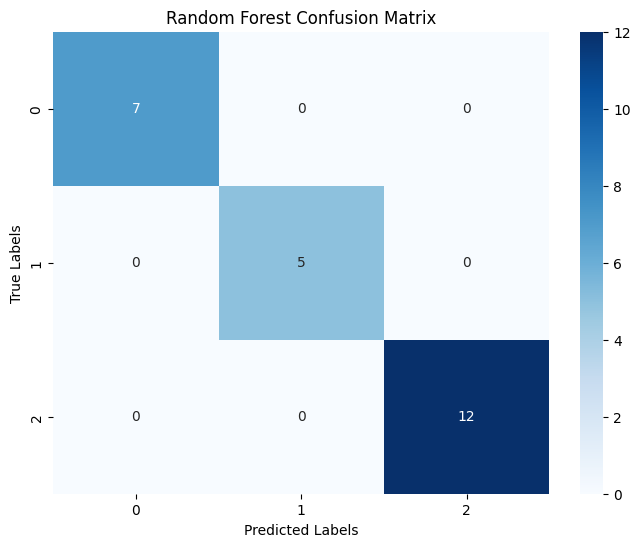

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for the Random Forest model
cm_rf = confusion_matrix(y_test, y_pred_rfdm)

#plotting confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(
cm_rf,
annot=True,
fmt='d',
cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [28]:
#3. Reinforcement Learning for Accident Prevention
import numpy as np
#states
states=["Lower Risk", "Medium Risk", "High Risk"]

#actions
actions=["Do Nothing", "Safety Campaign", "Increase Enforcement"]

#reward matrix
reward_matrix=np.array([
    [5, 8, 3],
    [2, 10, 7],
    [1, 4, 15]
])
print("Reward Matrix: ")
print(reward_matrix)


Reward Matrix: 
[[ 5  8  3]
 [ 2 10  7]
 [ 1  4 15]]


In [30]:
#Q-table
q_table=np.zeros((len(states),len(actions)))
print("Q-table: ")
print(q_table)

Q-table: 
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [31]:
#parameters

#Learning rate control
alpha=0.1
#Discount factor control
gemma=0.9
# episodes (one complete learning attempt)
episodes=1000



#Training
for  episode in range(episodes):
  #choose random state
  state=np.random.randint(0, len(states))

  #choose random action
  action=np.random.randint(0, len(actions))

  #get reward
  reward=reward_matrix[state, action]

  #Update Q-value
  q_table[state, action]=q_table[state, action]+ alpha * (
      reward + gemma * np.max(q_table[state])-q_table[state, action]
  )
print("Trained Q-Table: ")
print(q_table)



"""convergence means Q-Values stop changing eventually
Convergence occurs when the agent learn a stable policy and when further training produces very small changes.
"""

Trained Q-Table: 
[[ 47.71445358  50.51590273  44.91677417]
 [ 64.05997927  71.56141936  68.52822547]
 [ 87.82658936  91.28582495 103.25083778]]


'convergence means Q-Values stop changing eventually\nConvergence occurs when the agent learn a stable policy and when further training produces very small changes.\n'

In [32]:
#find best action for each state
best_actions=np.argmax(q_table, axis=1)

for state_idx, action_idx in enumerate(best_actions):
  print(
      f"state: {states[state_idx]} ->Best Action: {actions[action_idx]}"
  )


state: Lower Risk ->Best Action: Safety Campaign
state: Medium Risk ->Best Action: Safety Campaign
state: High Risk ->Best Action: Increase Enforcement


In [33]:
#System Integration
risk_mapping={
    0: "Medium Risk",
    1:"Lower Risk",
    2:"High Risk",
}

policy={
    "Lower Risk": "Safety Compaign",
    "Medium Risk": "Safety Campaign",
    "High Risk": "Increase Enforcement"
}

for prediction in y_pred_rfdm[: 10]:
  risk_state=risk_mapping[prediction]

  action=policy[risk_state]

  print(
      f"Predicted State: {risk_state} -> Recommended Action: {action} "

  )


Predicted State: High Risk -> Recommended Action: Increase Enforcement 
Predicted State: High Risk -> Recommended Action: Increase Enforcement 
Predicted State: Medium Risk -> Recommended Action: Safety Campaign 
Predicted State: High Risk -> Recommended Action: Increase Enforcement 
Predicted State: Medium Risk -> Recommended Action: Safety Campaign 
Predicted State: High Risk -> Recommended Action: Increase Enforcement 
Predicted State: High Risk -> Recommended Action: Increase Enforcement 
Predicted State: Medium Risk -> Recommended Action: Safety Campaign 
Predicted State: High Risk -> Recommended Action: Increase Enforcement 
Predicted State: Lower Risk -> Recommended Action: Safety Compaign 


In [34]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 39.9 MB/s eta 0:00:00


In [35]:
import fitz
import pandas as pd
import os

In [37]:
import fitz
import os

# Define the directory where PDF files are located
directory_path = "/content/drive/MyDrive/ML_Datasets"

pdf_files = []
for file_name in os.listdir(directory_path):
  if file_name.endswith('.pdf'):
    pdf_files.append(os.path.join(directory_path, file_name))

all_text=""

for pdf_file in pdf_files:
  # Check if the file exists and is not empty
  if os.path.exists(pdf_file) and os.path.getsize(pdf_file) > 0:
    try:
      doc = fitz.open(pdf_file)
      for page in doc:
        all_text += page.get_text()
      doc.close()
    except ValueError as e:
      print(f"Skipping encrypted or corrupted file: {pdf_file} - Error: {e}")
    except Exception as e:
      print(f"Skipping {pdf_file} due to an unexpected error: {e}")
  else:
    print(f"Skipping empty or non-existent file: {pdf_file}")

print(" Total number of texts extracted: ", len(all_text))
print("\nFirst 1000 characters of the extracted text:")
print(all_text[:1000])

 Total number of texts extracted:  1260651

First 1000 characters of the extracted text:
UNREVISED HANSARD 
MINI PLENARY - NATIONAL ASSEMBLY (VIRTUAL) 
THURSDAY, 13 NOVEMBER 2025 
Page: 1 
 
THURSDAY, 13 NOVEMBER 2025 
____ 
 
PROCEEDINGS OF THE NATIONAL ASSEMBLY 
____ 
 
Members of the mini-plenary session met on the virtual platform 
at 14:00. 
 
House Chairperson, Mr W Horn, took the Chair and requested 
members to observe a moment of silence for prayer or meditation. 
 
VIRTUAL SITTING RULES 
 
(Announcement) 
 
The HOUSE CHAIRPERSON (Mr W Horn): Hon members, before we 
proceed, I would like to remind you that the virtual mini plenary 
is deemed to be in the precinct of Parliament and constitutes a 
meeting of the National Assembly for the debating purposes only. 
In addition to the rules of the virtual sittings, the rules of 
the National Assembly, including the rules of debate apply. 
 
UNREVISED HANSARD 
MINI PLENARY - NATIONAL ASSEMBLY (VIRTUAL) 
THURSDAY, 13 NOVEMBER 2025 
Pag

In [38]:
import re
#covert to lowercase
clean_text=all_text.lower()

#remove page references
clean_text=re.sub(r'page:\s\d+', ' ',clean_text)

#remove extra whitespace
clean_text=re.sub(r'\s+', ' ',clean_text)

#remove all special characters
clean_text=re.sub(r'[^a-zA-Z0-9\s]', ' ',clean_text)

#remove numbers
clean_text=re.sub(r'\d+', ' ',clean_text)

#removing extra space again
clean_text=re.sub(r'\s+', ' ',clean_text).strip()

print("Cleaned text length: ", len(clean_text))
print("\nFirst 1000 characters of the cleaned text:")
print(clean_text[:1000])

Cleaned text length:  1174573

First 1000 characters of the cleaned text:
unrevised hansard mini plenary national assembly virtual thursday november thursday november proceedings of the national assembly members of the mini plenary session met on the virtual platform at house chairperson mr w horn took the chair and requested members to observe a moment of silence for prayer or meditation virtual sitting rules announcement the house chairperson mr w horn hon members before we proceed i would like to remind you that the virtual mini plenary is deemed to be in the precinct of parliament and constitutes a meeting of the national assembly for the debating purposes only in addition to the rules of the virtual sittings the rules of the national assembly including the rules of debate apply unrevised hansard mini plenary national assembly virtual thursday november members enjoy the same powers and privileges that apply in the sitting of the national assembly members should equally note that an

In [40]:
!pip install transformers sentence-transformers

In [41]:
from transformers import AutoTokenizer
tokenizer=AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)
tokens=tokenizer.tokenize(
    clean_text[:1000]
)
print("Number of tokens: ", len(tokens))
print("first 50 tokens: \n")
print(tokens[:50])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Number of tokens:  177
first 50 tokens: 

['un', '##re', '##vis', '##ed', 'hans', '##ard', 'mini', 'pl', '##enary', 'national', 'assembly', 'virtual', 'thursday', 'november', 'thursday', 'november', 'proceedings', 'of', 'the', 'national', 'assembly', 'members', 'of', 'the', 'mini', 'pl', '##enary', 'session', 'met', 'on', 'the', 'virtual', 'platform', 'at', 'house', 'chairperson', 'mr', 'w', 'horn', 'took', 'the', 'chair', 'and', 'requested', 'members', 'to', 'observe', 'a', 'moment', 'of']


In [42]:
from sentence_transformers import SentenceTransformer
embedding_model=SentenceTransformer(
    'all-MiniLM-L6-v2'
)
#split text into chunks
chunk_size=500

text_chunks=[
    clean_text[i:i+chunk_size]
    for i in range(0, len(clean_text), chunk_size)
]

print("Number of text chunks: ", len(text_chunks))

#embedding for first 100 chunks
sample_chunks=text_chunks[:100]

embeddings=embedding_model.encode(
    sample_chunks,
    show_progress_bar=True
)

print("Embedding Shape: ", embeddings.shape)


config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Number of text chunks:  2350


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Embedding Shape:  (100, 384)


In [43]:
#view chunks transcript
for i in range(10):
  print(f"\n--Chunks{i}---\n")
  print(text_chunks[i][:500])


--Chunks0---

unrevised hansard mini plenary national assembly virtual thursday november thursday november proceedings of the national assembly members of the mini plenary session met on the virtual platform at house chairperson mr w horn took the chair and requested members to observe a moment of silence for prayer or meditation virtual sitting rules announcement the house chairperson mr w horn hon members before we proceed i would like to remind you that the virtual mini plenary is deemed to be in the preci

--Chunks1---

nct of parliament and constitutes a meeting of the national assembly for the debating purposes only in addition to the rules of the virtual sittings the rules of the national assembly including the rules of debate apply unrevised hansard mini plenary national assembly virtual thursday november members enjoy the same powers and privileges that apply in the sitting of the national assembly members should equally note that anything said in the virtual platform is deem

In [44]:
import pandas as pd

sentiment_data = []

for chunk in text_chunks[:500]:

    text = chunk[:500].lower()

    if any(word in text for word in [
        "failed",
        "corruption",
        "crisis",
        "poverty",
        "unemployment"
    ]):
        sentiment_data.append([chunk[:500], "negative"])

    elif any(word in text for word in [
        "improve",
        "improved",
        "achievement",
        "successful",
        "progress",
        "support"
    ]):
        sentiment_data.append([chunk[:500], "positive"])

    elif any(word in text for word in [
        "committee",
        "meeting",
        "assembly",
        "chairperson",
        "report"
    ]):
        sentiment_data.append([chunk[:500], "neutral"])

sentiment_df = pd.DataFrame(
    sentiment_data,
    columns=["text", "sentiment"]
)

print(sentiment_df.shape)

print("\nClass Distribution:\n")
print(sentiment_df["sentiment"].value_counts())

(312, 2)

Class Distribution:

sentiment
neutral     198
negative     73
positive     41
Name: count, dtype: int64


In [45]:
sentiment_df["sentiment"].value_counts()

,count
sentiment,
neutral,198
negative,73
positive,41


In [46]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
sentiment_df['label']=label_encoder.fit_transform(
    sentiment_df['sentiment']
)

print(label_encoder.classes_)
print("\n")
print(sentiment_df.head())

['negative' 'neutral' 'positive']


                                                text sentiment  label
0  unrevised hansard mini plenary national assemb...   neutral      1
1  nct of parliament and constitutes a meeting of...   neutral      1
2  n option to allow a member to put up their han...   neutral      1
3  te i recognise the hon munyai unrevised hansar...  negative      0
4  he scourge of substance abuse it is not merely...  negative      0


In [47]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    sentiment_df['text'].tolist(),
    sentiment_df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=sentiment_df['label']
)

print("Training samples:", len(train_texts))
print("Testing samples:", len(test_texts))

Training samples: 249
Testing samples: 63


In [48]:
print(sentiment_df.shape)


(312, 3)


In [49]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained(
    'distilbert-base-uncased'
)

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

print("Tokenisation complete")

Tokenisation complete


In [50]:
import torch

class SentimentDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx]
        )

        return item

    def __len__(self):
        return len(self.labels)

In [51]:
train_dataset = SentimentDataset(
    train_encodings,
    train_labels
)

test_dataset = SentimentDataset(
    test_encodings,
    test_labels
)

print("Training dataset size:", len(train_dataset))
print("Testing dataset size:", len(test_dataset))

Training dataset size: 249
Testing dataset size: 63


In [52]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

print("Model loaded successfully")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully


In [53]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_dir="./logs",

    logging_steps=10
)

print("Training arguments created")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments created


In [54]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

print("Trainer created successfully")

Trainer created successfully


In [55]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.839056,0.868409
2,0.811717,0.818438
3,0.791661,0.795938


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=96, training_loss=0.8508578340212504, metrics={'train_runtime': 605.6602, 'train_samples_per_second': 1.233, 'train_steps_per_second': 0.159, 'total_flos': 24738727871232.0, 'train_loss': 0.8508578340212504, 'epoch': 3.0})

In [56]:
predictions = trainer.predict(test_dataset)

predicted_labels = predictions.predictions.argmax(axis=1)

print(predicted_labels[:10])

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[1 1 1 1 1 1 1 1 1 1]


In [57]:
print("Actual Labels:")
print(test_labels[:20])

print("\nPredicted Labels:")
print(predicted_labels[:20])

Actual Labels:
[1, 1, 1, 1, 0, 0, 1, 0, 2, 1, 1, 2, 1, 1, 0, 1, 1, 0, 2, 1]

Predicted Labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(
    test_labels,
    predicted_labels
)

precision = precision_score(
    test_labels,
    predicted_labels,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    test_labels,
    predicted_labels,
    average='weighted',
    zero_division=0
)

f1 = f1_score(
    test_labels,
    predicted_labels,
    average='weighted',
    zero_division=0
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:\n")
print(
    classification_report(
        test_labels,
        predicted_labels,
        zero_division=0
    )
)

Accuracy: 0.6349206349206349
Precision: 0.4031242126480222
Recall: 0.6349206349206349
F1 Score: 0.49314224071505625

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.63      1.00      0.78        40
           2       0.00      0.00      0.00         8

    accuracy                           0.63        63
   macro avg       0.21      0.33      0.26        63
weighted avg       0.40      0.63      0.49        63



In [59]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    test_labels,
    predicted_labels
)

print(cm)

[[ 0 15  0]
 [ 0 40  0]
 [ 0  8  0]]


In [63]:
import faiss
import numpy as np

# Convert embeddings
embeddings = np.array(embeddings).astype('float32')

# index
index = faiss.IndexFlatL2(
    embeddings.shape[1]
)

# Store vectors
index.add(embeddings)

print("Vectors stored:", index.ntotal)

Vectors stored: 100


In [64]:
query = "What was said about education policy?"

query_embedding = embedding_model.encode(
    [query]
).astype('float32')

k = 5

distances, indices = index.search(
    query_embedding,
    k
)

print("Retrieved Chunks:\n")

for idx in indices[0]:
    print("\n-------------------\n")
    print(text_chunks[idx][:1000])

Retrieved Chunks:


-------------------

se as a risk inaudible the impact is felt most by children children who go to bed hungry who drop out of school or who grow up without stability because a parent is caught in addiction hon house chairperson we must respond to this crisis with decisive action not just policy on paper we must treat substance abuse as both a health and security crisis flags are red already firstly we must take prevention seriously we need consistent and well funded awareness and early intervention programmes especi

-------------------

ed to ensure that we grow our economy as key among substance abuse triggers is the loss of hope as a result of lack of job opportunities for especially young people the da is unwavering in ensuring that economic growth is at the centre of all efforts to change the trajectory of all south african s futures otherwise hon members we will find ourselves here again not to rescue our people from addiction s grip but simply to tick another

In [65]:
# first 500 chunks

sample_chunks = text_chunks[:500]

embeddings = embedding_model.encode(
    sample_chunks,
    show_progress_bar=True
)

print(embeddings.shape)

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

(500, 384)


In [66]:
import faiss
import numpy as np

embeddings = np.array(embeddings).astype("float32")

index = faiss.IndexFlatL2(
    embeddings.shape[1]
)

index.add(embeddings)

print("Vectors stored:", index.ntotal)

Vectors stored: 500


In [67]:
query = "What was said about education policy?"

query_embedding = embedding_model.encode(
    [query]
).astype("float32")

distances, indices = index.search(
    query_embedding,
    5
)

for i, idx in enumerate(indices[0]):

    print(f"\n=== Result {i+1} ===\n")

    print(sample_chunks[idx][:1000])


=== Result 1 ===

after school periods and the journey to and from school their recruitment tactics are sophisticated using older students as distributors creating dependencies through free initial supplies and leveraging social networks to expand their market the inadequate security infrastructure at many schools particular in under resourced communities enables this infiltration law enforcement response remains inconsistent and reactive rather than preventive we cannot allow educational institutions to become m

=== Result 2 ===

officials to make sure that they are aware of the policy because they are the implementers also there are mpos that are quite important in our society who are also in assistance in dealing with this matter hence those workshops are taking place at the moment wherein we are taking all the interested groups through those training inaudible in training because it deals with the victims that are quite sensitive to deal with because of their vulnerability but al

In [95]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer_gen = AutoTokenizer.from_pretrained("google/flan-t5-base")
model_gen = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")

print("Tokenizer and Model loaded for generative QA")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Tokenizer and Model loaded for generative QA


In [96]:
# Cell functionality moved to direct model/tokenizer calls in cell `kuFIGNALmxW5`.
# This cell is no longer needed.

In [75]:
retrieved_context = "\n\n".join(
    [sample_chunks[idx] for idx in indices[0]]
)

prompt = f"""
Answer the question using only the provided context.

Context:
{retrieved_context}

Question:
What was said about education policy?

Answer:
"""

print(prompt[:1500])


Answer the question using only the provided context.

Context:
after school periods and the journey to and from school their recruitment tactics are sophisticated using older students as distributors creating dependencies through free initial supplies and leveraging social networks to expand their market the inadequate security infrastructure at many schools particular in under resourced communities enables this infiltration law enforcement response remains inconsistent and reactive rather than preventive we cannot allow educational institutions to become m

officials to make sure that they are aware of the policy because they are the implementers also there are mpos that are quite important in our society who are also in assistance in dealing with this matter hence those workshops are taking place at the moment wherein we are taking all the interested groups through those training inaudible in training because it deals with the victims that are quite sensitive to deal with because of

In [97]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer_gen = AutoTokenizer.from_pretrained(
    "google/flan-t5-base"
)

model_gen = AutoModelForSeq2SeqLM.from_pretrained(
    "google/flan-t5-base"
)

print("FLAN-T5 loaded successfully")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


FLAN-T5 loaded successfully


In [98]:
input_ids = tokenizer_gen(
    prompt,
    return_tensors="pt",
    truncation=True,
    max_length=512
).input_ids

outputs = model_gen.generate(
    input_ids,
    max_new_tokens=100
)

answer = tokenizer_gen.decode(
    outputs[0],
    skip_special_tokens=True
)

print(answer)

we cannot allow educational institutions to become m officials to make sure that they are aware of the policy because they are the implementers


In [100]:
print(sentiment_df)

                                                  text sentiment  label
0    unrevised hansard mini plenary national assemb...   neutral      1
1    nct of parliament and constitutes a meeting of...   neutral      1
2    n option to allow a member to put up their han...   neutral      1
3    te i recognise the hon munyai unrevised hansar...  negative      0
4    he scourge of substance abuse it is not merely...  negative      0
..                                                 ...       ...    ...
307   many other areas of lifestyle ways in which w...   neutral      1
308  he amount of salt obviously it is punishment t...   neutral      1
309  rt at the bottom by the top i mean going to a ...   neutral      1
310  shortage of screening centres for diabetes and...  negative      0
311  erefore there is something called social deter...  negative      0

[312 rows x 3 columns]


In [101]:
sentiment_df.to_csv(
    "hansard_sentiment_dataset.csv",
    index=False
)

print("Dataset saved successfully")

Dataset saved successfully


In [102]:
from google.colab import files

files.download("hansard_sentiment_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [103]:
df.to_csv(
    "preprocessed_accident_dataset.csv",
    index=False
)

print("Accident dataset saved successfully")

Accident dataset saved successfully


In [105]:
print(df.head)

<bound method NDFrame.head of      AccidentNo          Location  Police Force Accident Severity  \
0             1  Residential Area             2   Bumper Accident   
1             2  Residential Area             2   Bumper Accident   
2             3  Residential Area             2   Bumper Accident   
3             4  Residential Area             2   Bumper Accident   
4             5  Residential Area             2   Bumper Accident   
..          ...               ...           ...               ...   
115         116      Highway Area             2    Fatal Accident   
116         117      Highway Area             2    Fatal Accident   
117         118      Highway Area             2    Fatal Accident   
118         119      Highway Area             2    Fatal Accident   
119         120      Highway Area             2    Fatal Accident   

     Number of Vehicles  Vehicle Type Speed (km/h) Speed Zone  \
0                     6       Motocar       90km/h       60KM   
1          

In [106]:
from google.colab import files

files.download(
    "preprocessed_accident_dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>